# Ames Housing — Exploratory Data Analysis

Part 2 of the Ames Housing project. Continues from [`01_cleaning.ipynb`](./01_cleaning.ipynb),
which investigates and resolves all missing values in the raw dataset, producing `train_cleaned.csv`.

This notebook picks up from that cleaned checkpoint and covers univariate, bivariate, and
multivariate analysis — with a focus on testing assumptions rather than accepting surface-level
patterns, applying the same rigor built during an earlier Titanic EDA project from the outset
this time, rather than discovering it partway through.

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train_cleaned.csv", keep_default_na=False, na_values=[])
df["MSSubClass"] = df["MSSubClass"].astype(str)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000


## Setup

Recalculating column type groupings fresh from the cleaned data, since some dtypes changed
during cleaning (e.g. `MSSubClass` converted from numeric to string) and shouldn't be assumed
identical to the groupings used in the cleaning notebook.

In [118]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
object_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()

len(numeric_cols), len(object_cols)

(36, 44)

## SalePrice — Univariate Analysis

Starting with the target variable, since everything else in this analysis will eventually be
compared against it. Before looking at the data, my prediction was that `SalePrice` would be
right-skewed, similar to `Fare` in the Titanic dataset — most real-world price data clusters
around a typical value with a thinning tail of expensive outliers.

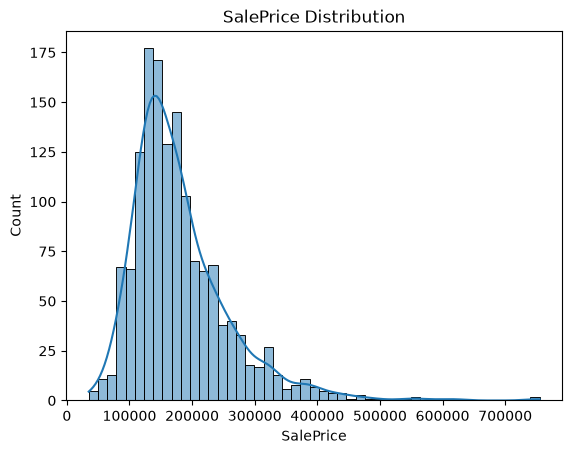

In [119]:
sns.histplot(data=df, x="SalePrice", kde=True)
plt.title("SalePrice Distribution")
plt.show()

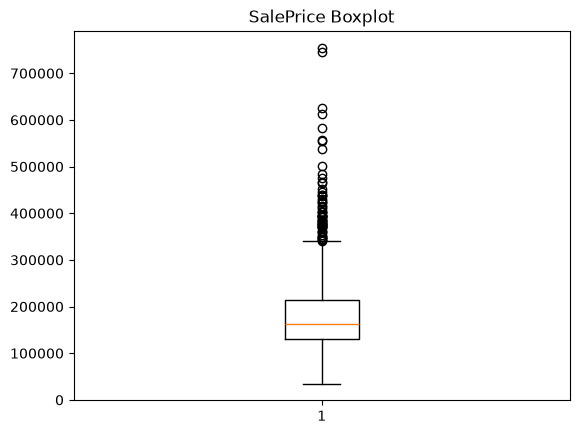

In [120]:
plt.boxplot(df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()

In [121]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

**Finding:** confirmed — `SalePrice` is right-skewed, with a skew coefficient of **1.3**, well past
the threshold for strong skew. The histogram shows a sharp peak at lower-to-mid price ranges with a
long tail stretching toward expensive homes, and the boxplot shows a compressed box with several
outlier dots above it.

In [122]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**Mean vs Median:** the mean (\$180,921) sits about \$18,000 above the median (\$163,000) — exactly
what you'd expect from right-skewed data, since a small number of high-value homes pull the mean
upward without moving the median nearly as much. The median is the more representative measure of
a "typical" Ames home; the mean is inflated by outliers.

## Identifying Outliers — IQR Method

Rather than relying on an arbitrary percentile cutoff, using the IQR (Interquartile Range) rule —
the same method boxplots use internally to determine which points are drawn as outlier dots.

In [123]:
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].sort_values(col, ascending=False)

    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    print(f"Total {col} Outliers: {len(outliers)}")

    return outliers[[col]]

find_outliers(df, "SalePrice")


Lower bound: 3937.5, Upper bound: 340037.5
Total SalePrice Outliers: 61


,SalePrice
691,755000
1182,745000
1169,625000
898,611657
803,582933
...,...
990,348000
642,345000
11,345000
320,342643


**Finding:** 61 houses qualify as outliers by the IQR rule, and **all of them are upper (high-price)
outliers** — there are no lower-end outliers. This makes sense given the calculated lower bound
(~\$3,937) is far below any realistic house price (actual minimum: \$34,900), so no house could ever
fall below it. This confirms `SalePrice`'s skew is entirely driven from the high end — a "some houses
are unusually expensive" story, not a "some houses are unusually cheap" one.

Next: examining what these 61 outlier houses have in common, without yet investigating *why* — that
belongs to bivariate/multivariate analysis.

In [124]:
outliers = find_outliers(df, "SalePrice")   # finds outlier ROWS based on SalePrice specifically

outliers_full = df.loc[outliers.index, ["SalePrice", "OverallQual", "BedroomAbvGr", "Neighborhood", "GrLivArea", "LotArea", "ExterCond", "ExterQual"]]
outliers_full

Lower bound: 3937.5, Upper bound: 340037.5
Total SalePrice Outliers: 61


,SalePrice,OverallQual,BedroomAbvGr,Neighborhood,GrLivArea,LotArea,ExterCond,ExterQual
691,755000,10,4,NoRidge,4316,21535,TA,Ex
1182,745000,10,4,NoRidge,4476,15623,TA,Gd
1169,625000,10,4,NoRidge,3627,35760,Gd,Gd
898,611657,9,2,NridgHt,2364,12919,TA,Ex
803,582933,9,4,NridgHt,2822,13891,TA,Ex
...,...,...,...,...,...,...,...,...
990,348000,8,3,NoRidge,2392,9452,TA,Gd
642,345000,8,4,NAmes,2704,13860,TA,Gd
11,345000,9,4,NridgHt,2324,11924,TA,Ex
320,342643,9,4,NridgHt,2596,16259,TA,TA


**Observed patterns (not yet statistically tested — real correlation checks come in bivariate):**
- `OverallQual` appears to track with `SalePrice` among these outliers.
- The outliers are heavily concentrated in `NoRidge` and `NridgHt` — worth checking in bivariate
  whether these neighborhoods are genuinely the highest-priced overall, or just overrepresented
  specifically among outliers.
- `GrLivArea` also appears to track with `SalePrice`, consistent with my original hypothesis.
- **`LotArea` does NOT appear to be a good proxy for price** — a direct reversal of part of my
  original Day-1 guess, where I expected land area to be one of the top drivers. Worth confirming
  with an actual correlation number, but the raw values here don't show a consistent pattern.
- `ExterCond` and `ExterQual` are mostly TA (Typical/Average) or better across these outliers —
  makes intuitive sense, since a poorly-maintained exterior would be unlikely to support a
  top-tier sale price.

**Important caveat:** this is only a look at houses *already selected* for being expensive — of
course quality and size look high within that group. This can't yet prove these features drive
price *in general* across the full dataset. The real test is checking correlation with `SalePrice`
across all 1460 houses, which belongs in the bivariate section.

## Fast Scan — Full Column Sweep

Before deep-diving into specific columns, running a lightweight scan across every numeric and
categorical column to catch anything worth flagging — high skew, narrow/wide ranges, or a
categorical column dominated by a single value (like `Street` was found to be during cleaning).
This determines which columns deserve full univariate treatment versus which can be left as
"checked, nothing unusual" without a dedicated chart.

In [125]:
df[numeric_cols].describe()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.398630,443.639726,46.549315,567.240411,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,46.228767,6.321918,2007.815753,180921.195890
std,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.730605,456.098091,161.319273,441.866955,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,504.439884,2.703626,1.328095,79442.502883
min,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [126]:
for col in object_cols:
    print(col, "→", df[col].value_counts(normalize=True).head(1).to_dict())

MSSubClass → {'20': 0.36712328767123287}
MSZoning → {'RL': 0.7883561643835616}
Street → {'Pave': 0.9958904109589041}
Alley → {'None': 0.9376712328767123}
LotShape → {'Reg': 0.6335616438356164}
LandContour → {'Lvl': 0.897945205479452}
Utilities → {'AllPub': 0.9993150684931507}
LotConfig → {'Inside': 0.7205479452054795}
LandSlope → {'Gtl': 0.9465753424657535}
Neighborhood → {'NAmes': 0.1541095890410959}
Condition1 → {'Norm': 0.863013698630137}
Condition2 → {'Norm': 0.9897260273972602}
BldgType → {'1Fam': 0.8356164383561644}
HouseStyle → {'1Story': 0.49726027397260275}
RoofStyle → {'Gable': 0.7815068493150685}
RoofMatl → {'CompShg': 0.9821917808219178}
Exterior1st → {'VinylSd': 0.3527397260273973}
Exterior2nd → {'VinylSd': 0.3452054794520548}
MasVnrType → {'None': 0.5938356164383561}
ExterQual → {'TA': 0.6205479452054794}
ExterCond → {'TA': 0.8780821917808219}
Foundation → {'PConc': 0.44315068493150683}
BsmtQual → {'TA': 0.44452054794520546}
BsmtCond → {'TA': 0.897945205479452}
BsmtExposu

## MoSold — Flagged from the Fast Scan

`MoSold` stood out during the initial scan as numeric, but conceptually more like a category —
worth a closer look before deciding how to treat it.

In [127]:
df["MoSold"].dtype, df["MoSold"].unique()


(dtype('int64'), array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6]))

## MoSold

Stored as a number but conceptually categorical — no real ranking between months, though month
does carry a genuine cyclical relationship (December sits close to January seasonally). Checked
for a pattern before deciding on treatment.

In [128]:
df.groupby("MoSold")["SalePrice"].agg(["mean", "count"]).sort_values("count", ascending=False)

,mean,count
MoSold,,
6,177395.735178,253
7,186331.192308,234
5,172307.269608,204
4,171503.262411,141
8,184651.827869,122
3,183253.924528,106
10,179563.977528,89
11,192210.911392,79
9,195683.206349,63


**Finding:** May–July show the highest sales volume, consistent with the typical US spring/summer
moving season. September shows the highest average `SalePrice`, April the lowest — worth testing
properly in bivariate analysis rather than concluding anything further here.

## OverallQual — Univariate Analysis

Moving to `OverallQual`, one of the strongest candidates identified during the outlier review
earlier — high overall quality appeared consistently among the most expensive houses. Before
looking at the distribution, my prediction is that this column is right-skewed, following the
same pattern as most of the other columns checked so far this week.

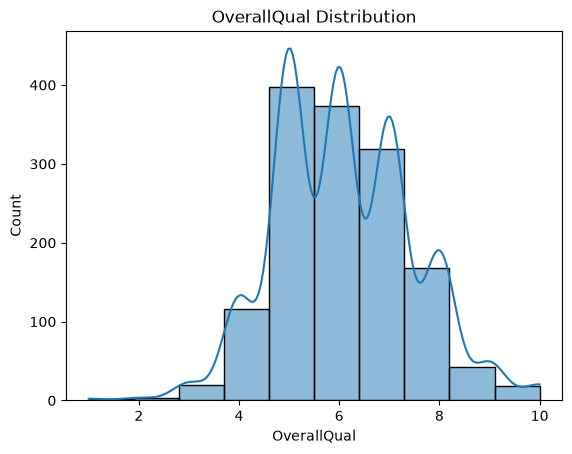

In [129]:
sns.histplot(data=df, x="OverallQual" , kde=True, bins=10)
plt.title("OverallQual Distribution")
plt.show()

In [130]:
df["OverallQual"].skew()

np.float64(0.2169439277628693)

**Finding:** `OverallQual` has a skew of **0.22** — essentially no skew, unlike every price/area
column checked so far this week. My prediction (right-skewed, like `SalePrice`) was wrong, and I
think I know why: unlike `SalePrice`, `OverallQual` has a fixed minimum and maximum (a 1–10 rating
scale). That doesn't fully prevent outliers from existing, but it structurally limits how extreme
they can get compared to an open-ended column like price.

The histogram peaks around 5, which fits a near-normal distribution — mean and median sit close
together exactly as you'd expect when skew is near zero. There also appear to be more low-quality
outliers than high-quality ones on the chart.

**Hypothesis (untested):** the concentration around average-to-above-average quality may reflect
`OverallQual` acting as a rough proxy for social/economic status — most of a population sits in a
"middle" bracket, and middle-class buyers often stretch toward homes slightly above their own
level as a form of status signaling. This is speculative and not something this dataset can
directly confirm, but it's a plausible explanation for why the distribution centers where it does
rather than skewing toward either extreme.

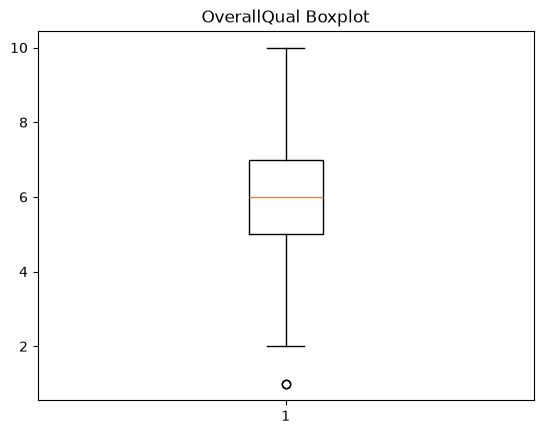

In [131]:
plt.boxplot(df["OverallQual"])
plt.title("OverallQual Boxplot")
plt.show()

In [132]:
find_outliers(df, "OverallQual")

Lower bound: 2.0, Upper bound: 10.0
Total OverallQual Outliers: 2


,OverallQual
375,1
533,1


**Boxplot confirmation:** only **2 outliers** in `OverallQual`, both rated **1** — the lowest
possible score on the scale. This is the mirror opposite of `SalePrice`, where all 61 outliers
sat on the *high* end with none on the low end. Here, it's the reverse: genuinely poor-quality
houses are rare enough in this dataset to register as outliers, while excellent-quality houses
are common enough (given the average-to-above-average clustering already found) not to stand out
statistically.

## GrLivArea — Univariate Analysis

Moving to `GrLivArea` (above-ground living area), the second core column from the original Day-1
hypothesis and confirmed relevant in the outlier review earlier. As a raw area measurement — same
category as `LotArea`, `Fare`, and `MasVnrArea` — my prediction is that this will be right-skewed,
consistent with every other area/money column checked so far this week.

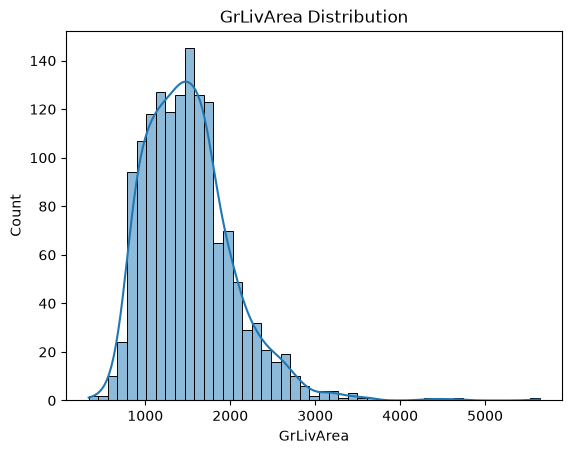

In [133]:
sns.histplot(data=df, x="GrLivArea", kde=True)
plt.title("GrLivArea Distribution")
plt.show()

In [134]:
df["GrLivArea"].skew()

np.float64(1.3665603560164552)

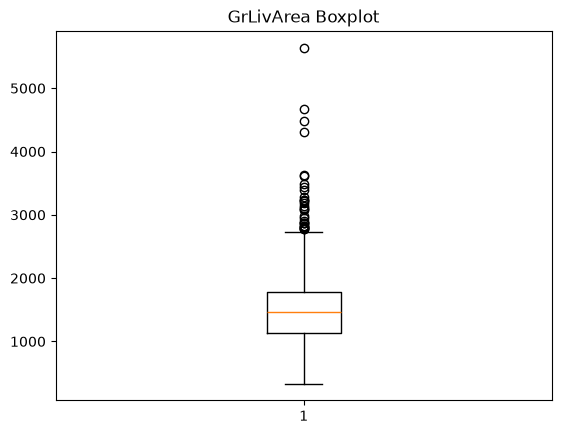

In [135]:
plt.boxplot(df["GrLivArea"])
plt.title("GrLivArea Boxplot")
plt.show()

In [136]:
find_outliers(df, "GrLivArea")

Lower bound: 158.625, Upper bound: 2747.625
Total GrLivArea Outliers: 31


,GrLivArea
1298,5642
523,4676
1182,4476
691,4316
1169,3627
185,3608
304,3493
1268,3447
635,3395
769,3279


**Boxplot confirmation:** all outliers in `GrLivArea` fall above the upper bound — no low-end
outliers, matching the pattern already seen in `SalePrice`. This confirms my hunch going in: for
open-ended measurements like size and price, big/expensive tends to be the rare case, not
small/cheap.

## Neighborhood — Univariate Analysis

Moving to `Neighborhood`, the third core column from the original Day-1 hypothesis and already
flagged as relevant during the outlier review (`NoRidge` and `NridgHt` were heavily overrepresented
among the most expensive houses). Unlike the previous columns, this is categorical, not numeric —
so this section uses `value_counts()` and a bar chart rather than a histogram/boxplot/skew check.

Before looking at the actual counts, my prediction is that representation across the ~25
neighborhoods is uneven, with a handful of neighborhoods containing far more houses than others.

In [137]:
df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

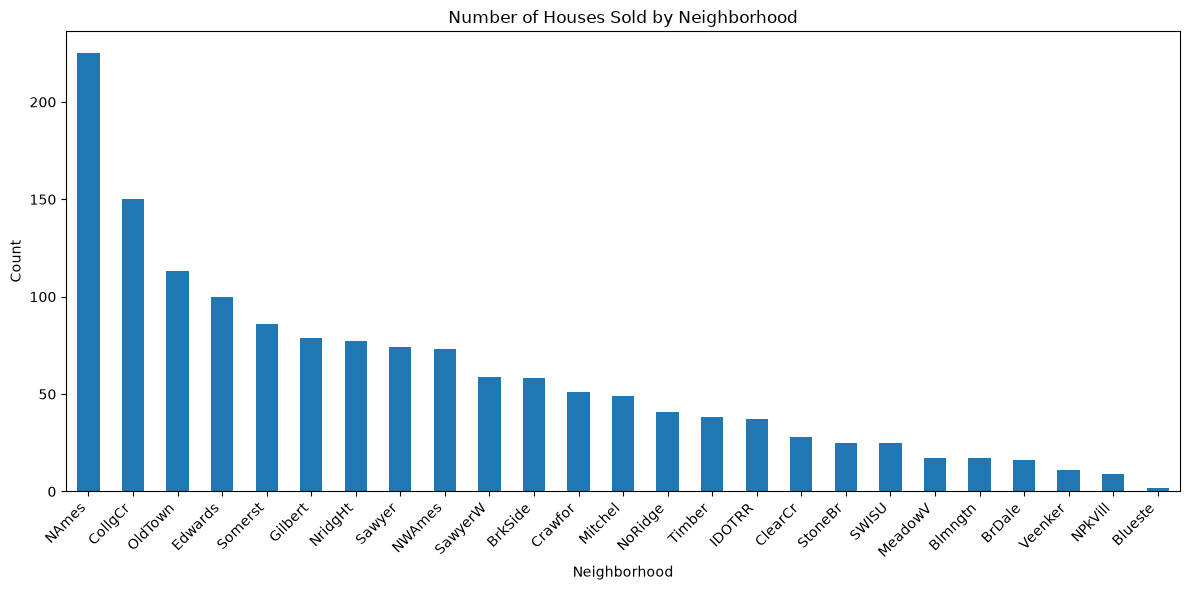

In [138]:
plt.figure(figsize=(12, 6))
df["Neighborhood"].value_counts().plot(kind="bar")
plt.title("Number of Houses Sold by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Finding:** `NAmes` is by far the most common neighborhood, with roughly **150% more sales**
than the runner-up — a genuinely dominant concentration, not a close call. At the other end,
several neighborhoods are quite sparse: `MeadowV` and `Blmngtn` (17 each), `BrDale` (16),
`Veenker` (11), `NPkVill` (9), and especially `Blueste` at just **2 houses total**. Any
conclusion tied specifically to `Blueste` should be treated with real caution given how thin
that sample is.

**Flagged for bivariate:** my prediction was that `NAmes`, being the most common neighborhood,
would sell around the overall median `SalePrice` (~\$163,000) — this can't be tested at the
univariate level and needs a `groupby("Neighborhood")["SalePrice"].mean()` check later.

## LotArea — Univariate Analysis

Moving to `LotArea`, the last of the original Day-1 hypothesis columns. As a raw area measurement,
consistent with `GrLivArea`, `Fare`, and `MasVnrArea` checked earlier, my prediction is that this
will also be right-skewed — worth remembering, though, that the earlier outlier check found
`LotArea` did NOT look like a strong price proxy among the 61 outlier houses, unlike `GrLivArea`.
This will be worth revisiting once bivariate analysis can test it properly.

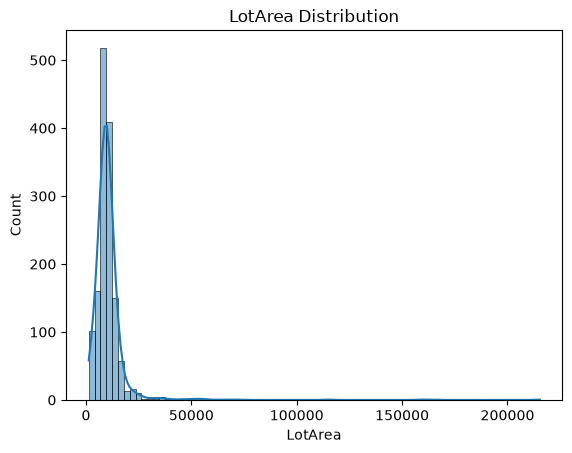

In [139]:
sns.histplot(data=df, x="LotArea", kde=True)
plt.title("LotArea Distribution")
plt.show()

In [140]:
df["LotArea"].skew()

np.float64(12.207687851233496)

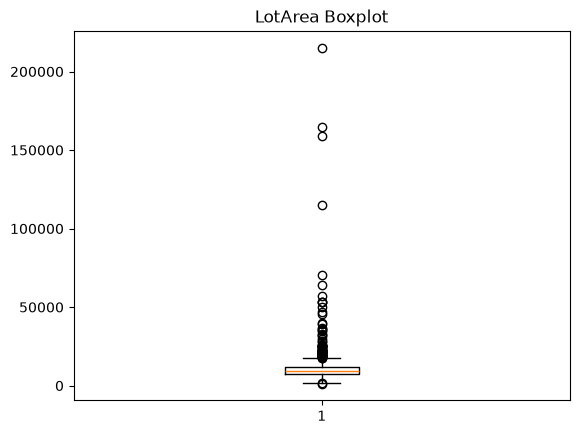

In [141]:
plt.boxplot(df["LotArea"])
plt.title("LotArea Boxplot")
plt.show()

In [142]:
df["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [143]:
find_outliers(df, "LotArea")

Lower bound: 1481.5, Upper bound: 17673.5
Total LotArea Outliers: 69


,LotArea
313,215245
335,164660
249,159000
706,115149
451,70761
...,...
854,17920
1277,17871
1151,17755
1039,1477


**Finding:** `LotArea` has a skew of **12.2** — by far the most extreme skew found this week,
driven by a huge gap between the median (9,478) and max (215,245, over 22x the median). The 25th
and 75th percentiles sit close together (7,553–11,601), consistent with the idea that lot sizes
within a given area tend to be fairly uniform, with a small number of much larger or smaller
exceptions.

IQR check found 69 outliers, with the top value (215,245) sitting well ahead of the next-highest
(~164,660). Investigated this single top outlier directly to check whether it looked like a real
property or a likely data error: it's also a `SalePrice` outlier, has an unremarkable `GrLivArea`,
and an `OverallQual` of 7 — a solid but not extreme rating. Looking at the row directly, it's an
old, irregularly-shaped, single-storey house with no fence — a profile consistent with a
genuinely large, older-style lot rather than a data entry mistake.

**Note:** this only verifies the single top outlier — it doesn't confirm all 69 outliers are
legitimate, and no further individual rows were checked. Worth treating the rest of the group with
appropriate caution if referenced later, rather than assuming the same story applies to all of them.

# Bivariate & Multivariate Analysis

Testing the specific hypotheses flagged during univariate analysis, rather than starting from
scratch — several predictions were deliberately left untested until this section:

- Does `NAmes`, the most common neighborhood, actually sell near the overall median `SalePrice`?
- Does `OverallQual` correlate with `SalePrice`, as suggested by the outlier review?
- Does `GrLivArea` correlate with `SalePrice`?
- Is `LotArea` really a weak price proxy, as it appeared among the outlier houses?
- Do `NoRidge` and `NridgHt` actually have the highest average prices, or were they just
  overrepresented among the outliers specifically?

Starting with a full correlation heatmap for a broad overview, before testing each hypothesis
individually.

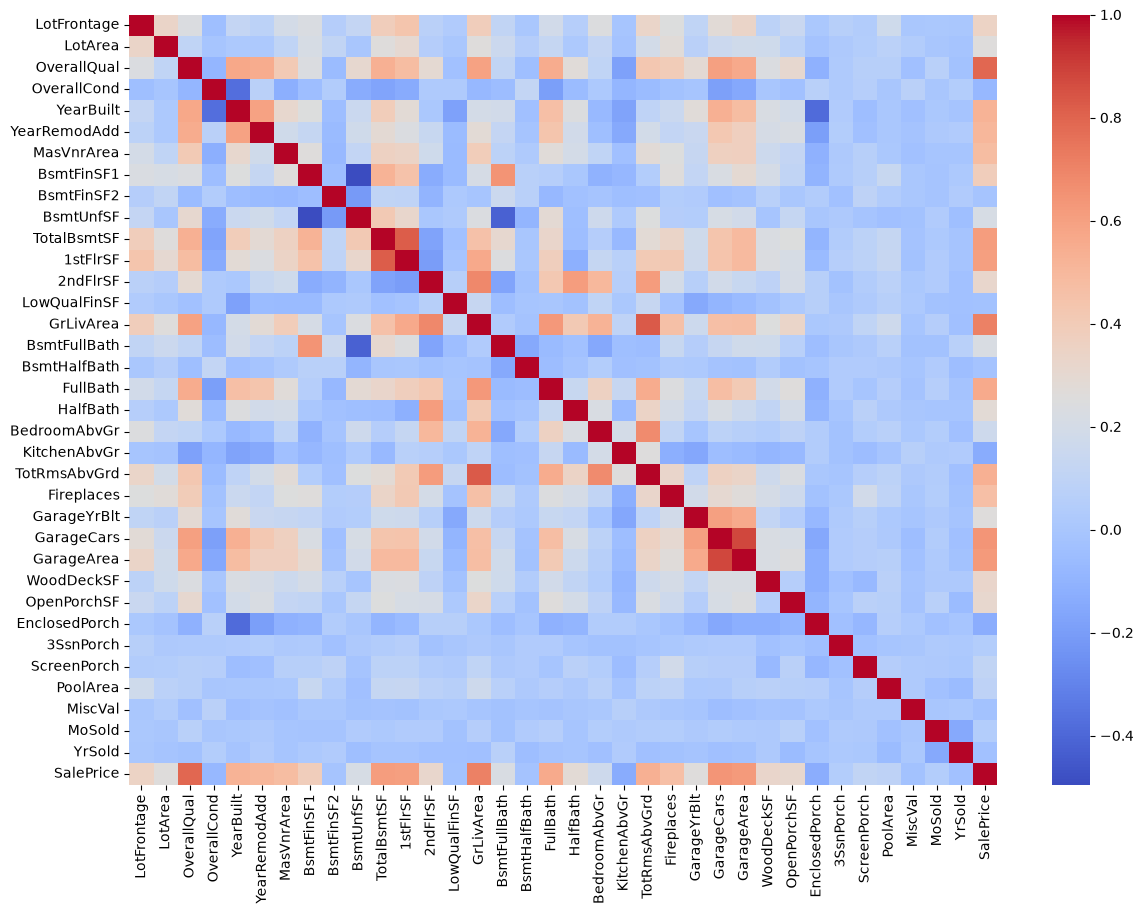

In [144]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.show()

## Testing Correlations Against SalePrice

In [145]:
cols_to_check = ["OverallQual", "GrLivArea", "LotArea", "TotalBsmtSF", "YearBuilt", "GarageArea","TotRmsAbvGrd","SalePrice"]
df[cols_to_check ].corr()["SalePrice"]

OverallQual     0.790982
GrLivArea       0.708624
LotArea         0.263843
TotalBsmtSF     0.613581
YearBuilt       0.522897
GarageArea      0.623431
TotRmsAbvGrd    0.533723
SalePrice       1.000000
Name: SalePrice, dtype: float64

**Verdict on the original Day-1 hypothesis** (land area, location, room count as top predictors):

- **Living area (`GrLivArea`) — confirmed strong**, second only to `OverallQual`, matching the
  original prediction.
- **Room count (`TotRmsAbvGrd`) — moderate, mixed result.** A real correlation (0.53), but
  meaningfully weaker than the top predictors and roughly tied with `YearBuilt`, a column that
  wasn't even part of the original hypothesis.
- **Land area (`LotArea`) — hypothesis not supported.** By far the weakest correlation of the
  group (0.26), confirming the pattern already seen in the outlier review — this wasn't a fluke
  of that biased subset, it holds across the full dataset.

**Genuinely the strongest predictor overall is `OverallQual`** (0.79) — not part of the original
Day-1 guess at all, but confirmed here as the single most important numeric feature checked so far,
consistent with the pattern already noticed in the earlier outlier review.

Location (`Neighborhood`) still needs to be tested separately, since it's categorical and wasn't
included in this correlation check.

## Testing Neighborhood — The Remaining Piece of the Day-1 Hypothesis

`Neighborhood` is categorical, so it can't be checked with `.corr()` the way the numeric columns
were — same distinction learned during the Titanic project. Using `groupby("Neighborhood")["SalePrice"].mean()`
instead, to test two specific flagged questions from univariate analysis:

1. Does `NAmes` (the most common neighborhood by sales volume) sell near the overall median
   `SalePrice` (~\$163,000), as predicted?
2. Do `NoRidge` and `NridgHt` (heavily overrepresented among the price outliers) actually have the
   highest average prices overall, or were they just overrepresented specifically among that
   biased outlier subset?

In [146]:
df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

## NAmes Investigation → YearBuilt/OverallQual Relationship

Investigating why `NAmes`, the most common neighborhood by sales volume, sits below the median
`SalePrice`. Original hypothesis: `NAmes` houses would be old (predicted) and average-to-above
quality (~7, predicted).

In [147]:
df[df["Neighborhood"] == "NAmes"][["YearBuilt", "OverallQual"]].describe()

,YearBuilt,OverallQual
count,225.000000,225.000000
mean,1959.995556,5.360000
std,8.770638,0.823321
min,1918.000000,3.000000
25%,1955.000000,5.000000
50%,1960.000000,5.000000
75%,1965.000000,6.000000
max,1998.000000,8.000000


## Does YearBuilt Correlate with OverallQual, in General?

The `NAmes` investigation found genuinely old houses (median 1960) paired with only average
`OverallQual` (median 5, not the 7 originally predicted). Worth checking whether this age/quality
relationship holds across the *whole* dataset, or whether it's specific to `NAmes` — testing this
before assuming older houses generally rate lower in quality.

In [148]:
df["YearBuilt"].corr(df["OverallQual"])

np.float64(0.5723227689623617)

**Finding:** `0.57` — a genuine, moderate positive correlation across the whole dataset. Older
houses do tend to rate lower on quality generally, not just within `NAmes`. Worth testing whether
this is a direct relationship, or whether `Neighborhood` (already shown to vary in both age and
price) is acting as a confounder.

In [149]:
df.groupby("Neighborhood").apply(lambda x: x["YearBuilt"].corr(x["OverallQual"]))

c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Neighborhood
Blmngtn   -0.343897
Blueste         NaN
BrDale     0.430644
BrkSide   -0.429656
ClearCr    0.256139
CollgCr    0.693755
Crawfor    0.312907
Edwards    0.473619
Gilbert    0.481350
IDOTRR     0.021337
MeadowV    0.610838
Mitchel    0.466844
NAmes      0.163436
NPkVill         NaN
NWAmes     0.386981
NoRidge    0.245941
NridgHt    0.261178
OldTown   -0.211282
SWISU      0.246306
Sawyer     0.174412
SawyerW    0.482771
Somerst    0.244616
StoneBr    0.501597
Timber     0.695601
Veenker    0.637859
dtype: float64

**Finding:** the correlation varies widely by neighborhood — from strongly negative (`BrkSide`
-0.43, `Blmngtn` -0.34) to strongly positive (`Timber` 0.70, `Veenker` 0.64), with `NAmes` itself
dropping to just 0.16. `Blueste` and `NPkVill` returned `NaN` — both have too few houses (2 and 9
respectively) for a meaningful correlation to be calculated.

**Verdict: `Neighborhood` is NOT a clean confounder here.** A true confounder (like `Pclass` for
Embarked/Survived in the Titanic project) shrinks a relationship toward zero everywhere once
controlled for, because the entire apparent relationship was borrowed from it. Here, several
neighborhoods actually show a *stronger* correlation than the overall 0.57, not a weaker one —
meaning `YearBuilt` and `OverallQual` have a real, direct relationship of their own. `Neighborhood`
does appear to *interact* with the strength of that relationship, but doesn't explain it away.
Not pursuing further confounder candidates — this is a reasonable stopping point for this
particular question.

## GarageArea, TotalBsmtSF, TotRmsAbvGrd — Quick Review

These three columns showed moderate-to-strong correlation with `SalePrice` in the earlier
correlation check (0.62, 0.61, and 0.53 respectively), but weren't originally part of the Day-1
hypothesis. Taking a quick look at their distributions before deciding whether any deserve a
deeper investigation.

In [150]:
cols = ["GarageArea", "TotalBsmtSF", "TotRmsAbvGrd"]

df[cols].describe()

,GarageArea,TotalBsmtSF,TotRmsAbvGrd
count,1460.000000,1460.000000,1460.000000
mean,472.980137,1057.429452,6.517808
std,213.804841,438.705324,1.625393
min,0.000000,0.000000,2.000000
25%,334.500000,795.750000,5.000000
50%,480.000000,991.500000,6.000000
75%,576.000000,1298.250000,7.000000
max,1418.000000,6110.000000,14.000000


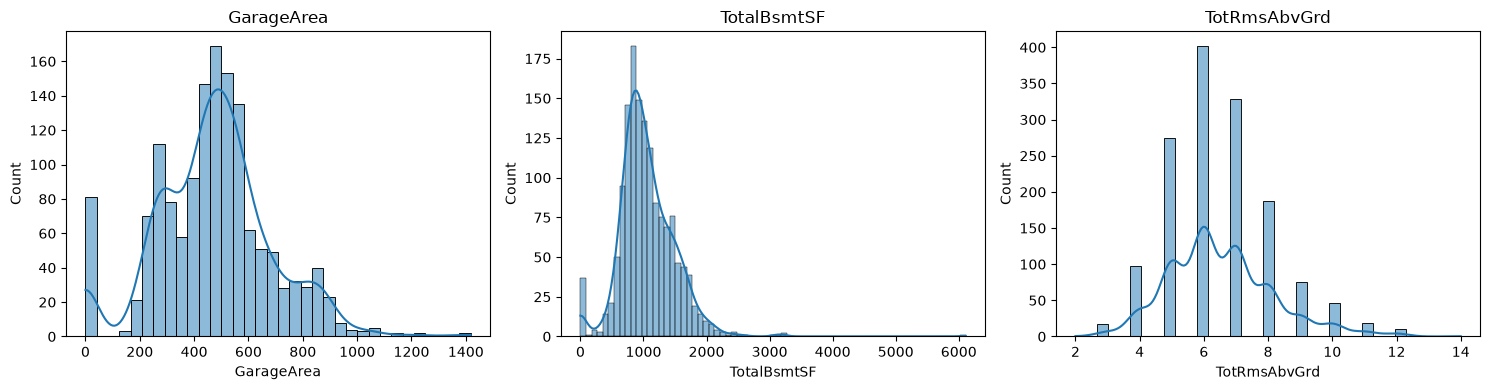

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

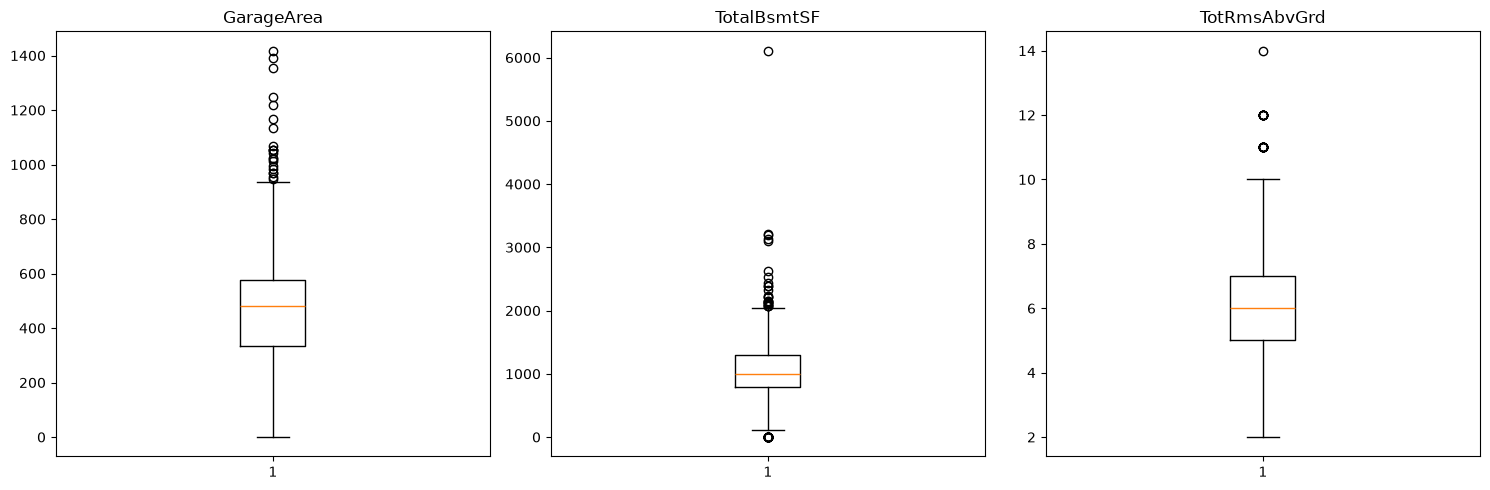

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols):
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()

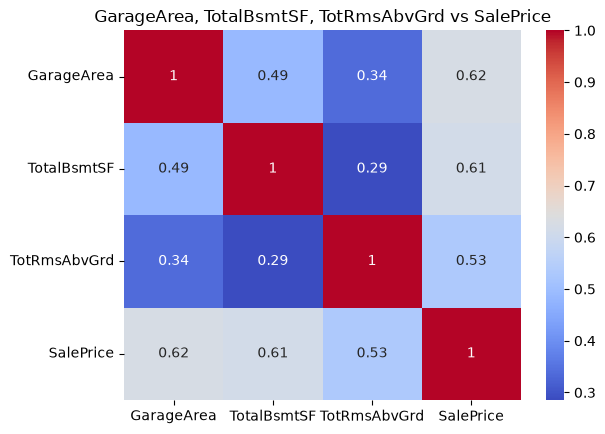

In [153]:
sns.heatmap(df[cols + ["SalePrice"]].corr(), annot=True, cmap="coolwarm")
plt.title("GarageArea, TotalBsmtSF, TotRmsAbvGrd vs SalePrice")
plt.show()

**Closing note:** `GarageArea`, `TotalBsmtSF`, and `TotRmsAbvGrd` all show moderate-to-strong
correlation with `SalePrice` (0.62, 0.61, 0.53 respectively) — real, legitimate findings on their
own. No further investigation pursued here; these are secondary columns without a specific
hypothesis or surprising pattern worth chasing deeper, unlike `OverallQual`/`YearBuilt`/`Neighborhood`
earlier.

## MoSold vs SalePrice — Bivariate Test

`MoSold` was flagged back in univariate analysis but never formally tested against `SalePrice`.
Two findings from that earlier pass: April showed the lowest average price and September the
highest, while May–July showed the highest sales volume (consistent with the typical spring/summer
moving season). Testing whether month sold shows any real relationship with price now, at the
bivariate level.

In [154]:
df.groupby("MoSold")["SalePrice"].mean().sort_index()

MoSold
1     183256.258621
2     177882.000000
3     183253.924528
4     171503.262411
5     172307.269608
6     177395.735178
7     186331.192308
8     184651.827869
9     195683.206349
10    179563.977528
11    192210.911392
12    186518.966102
Name: SalePrice, dtype: float64

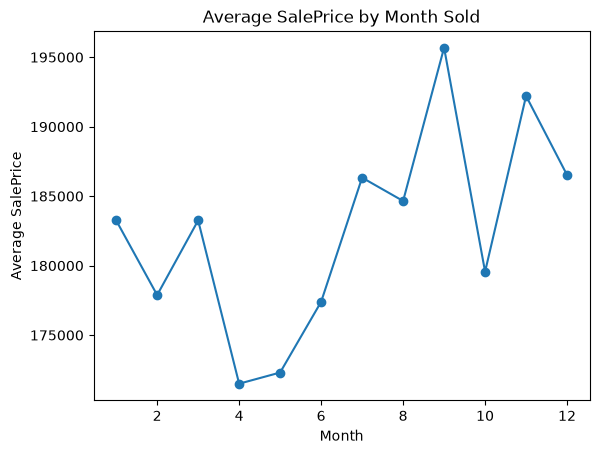

In [155]:
df.groupby("MoSold")["SalePrice"].mean().sort_index().plot(kind="line", marker="o")
plt.title("Average SalePrice by Month Sold")
plt.xlabel("Month")
plt.ylabel("Average SalePrice")
plt.show()

In [156]:
df.groupby("MoSold")["SalePrice"].count().sort_index()

MoSold
1      58
2      52
3     106
4     141
5     204
6     253
7     234
8     122
9      63
10     89
11     79
12     59
Name: SalePrice, dtype: int64

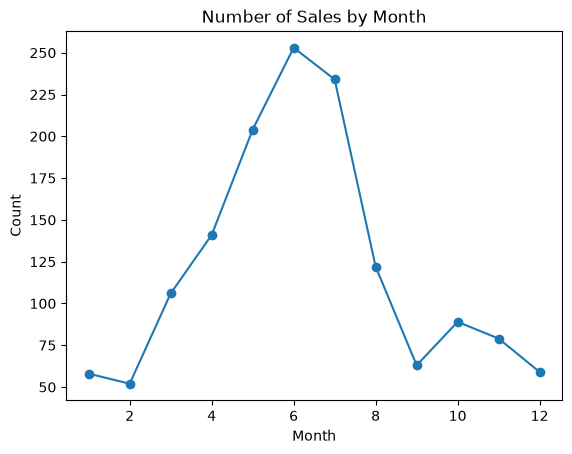

In [157]:
df.groupby("MoSold")["SalePrice"].count().sort_index().plot(kind="line", marker="o")
plt.title("Number of Sales by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

In [158]:
monthly_stats = df.groupby("MoSold")["SalePrice"].agg(["mean", "count"])
monthly_stats["mean"].corr(monthly_stats["count"])

np.float64(-0.4128464048575746)

## Why Does SalePrice Vary by Month? — Resolving the Pattern

Checking whether house characteristics differ by month, to test whether the earlier price/volume
pattern is actually a seasonal effect, or driven by something else entirely.

In [159]:
df.groupby("MoSold")[["OverallQual", "GrLivArea"]].mean().sort_index() 

,OverallQual,GrLivArea
MoSold,,
1,5.862069,1535.327586
2,6.269231,1460.711538
3,6.122642,1535.245283
4,6.042553,1456.673759
5,5.906863,1443.421569
6,6.019763,1501.225296
7,6.085470,1543.401709
8,6.131148,1562.385246
9,6.460317,1640.047619


**Finding — the mystery resolves, and it overturns the original framing:** September, the
highest-priced month, also has the highest average `OverallQual` and `GrLivArea`. The price
pattern isn't a seasonal effect at all — it's simply that September's houses are objectively
bigger and higher-quality on average. Month is correlating with price only because it's a proxy
for *what kind* of house tends to sell in a given month, not because timing itself affects value.

This also reframes the earlier volume/price correlation (-0.41): rather than "high volume causes
lower prices," it's more likely that peak moving season (May–July) draws a large pool of typical,
mid-market family buyers, diluting the average with more ordinary homes — while quieter months
like September have a smaller pool that happens to include more higher-end properties.

**Conclusion:** `MoSold` shows a real statistical pattern with `SalePrice`, but it is not a
meaningful direct predictor on its own — the underlying driver is house quality and size, the same
two features already confirmed as the strongest predictors in this dataset. Closing this
investigation here.

## MoSold — Final Summary

Two separate patterns investigated and resolved:

- **Price:** September's higher average `SalePrice` isn't a seasonal effect — it's explained by
  September's houses being objectively bigger and higher-quality on average. Month acts as a proxy
  for *what kind* of house tends to sell, not a direct driver of value.
- **Volume:** May–July's higher sales counts don't have a data-driven explanation within this
  dataset — this reflects real-world seasonal behavior (better weather for moves/showings, timed
  around the school calendar), not something explainable by house characteristics the way price was.

**Conclusion:** `MoSold` shows real statistical patterns with `SalePrice`, but neither is a
meaningful direct predictor on its own — price is fully explained by house quality/size (already
confirmed as the dataset's strongest drivers), and volume is a real-world seasonal effect outside
what this dataset can explain. Closing this investigation here.

## Why Is LotArea Such a Weak Predictor? — Testing Two Theories

`LotArea` showed by far the weakest correlation with `SalePrice` (0.26) among the core numeric
features. Testing two possible explanations before accepting the weakness as unexplained.

**Theory 1: Does LotArea correlate more strongly within individual neighborhoods** than it does
across the whole (highly varied) dataset?

In [160]:
neighborhood_counts = df["Neighborhood"].value_counts()
reliable_neighborhoods = neighborhood_counts[neighborhood_counts >= 10].index

lot_area_corr = df[df["Neighborhood"].isin(reliable_neighborhoods)].groupby("Neighborhood").apply(
    lambda x: x["LotArea"].corr(x["SalePrice"])
)
lot_area_corr.sort_values(ascending=False)

Neighborhood
MeadowV    0.860518
Somerst    0.708892
NridgHt    0.700336
StoneBr    0.700292
Veenker    0.697285
BrkSide    0.639110
OldTown    0.615990
ClearCr    0.573157
SawyerW    0.538432
NAmes      0.477291
SWISU      0.406711
Blmngtn    0.378529
NoRidge    0.378220
CollgCr    0.377198
BrDale     0.363236
Sawyer     0.322230
NWAmes     0.258061
Edwards    0.239335
Timber     0.223482
Crawfor    0.201784
Gilbert    0.157257
IDOTRR     0.130044
Mitchel   -0.059413
dtype: float64

Filtered out neighborhoods with fewer than 10 houses first — smaller groups (like `Blueste` at 2
houses) produce mathematically meaningless correlations (any 2-point group shows a false-perfect
±1.0, since two points always lie on a straight line). Results were mixed across neighborhoods,
not a clean confirmation either way.

**Theory 2: Does a neighborhood's lot-size consistency predict how strongly LotArea correlates
with price there?** Hypothesis: neighborhoods with more *uniform* lot sizes should show a
*stronger* LotArea/SalePrice relationship, since any variation there is more meaningful relative
to the norm — while neighborhoods with wildly varying lots would show a weaker relationship, since
size differences there are just normal noise.

In [161]:
grouped = df.groupby("Neighborhood")["LotArea"]
cv = (grouped.std() / grouped.mean()) * 100
cv.sort_values(ascending=False)

Neighborhood
Timber     173.573131
ClearCr    112.636544
StoneBr     92.694598
Veenker     75.821305
Edwards     68.765415
Mitchel     51.838128
NoRidge     51.569584
Somerst     47.736797
Crawfor     45.008337
MeadowV     41.132647
Gilbert     41.123877
OldTown     39.423120
BrkSide     36.877830
NPkVill     36.640373
NridgHt     33.412595
Sawyer      33.044223
NAmes       32.052917
IDOTRR      31.404051
SWISU       30.789619
Blueste     28.284271
CollgCr     24.376128
SawyerW     22.799650
NWAmes      22.672659
Blmngtn     10.945135
BrDale      10.766010
Name: LotArea, dtype: float64

In [162]:
comparison = pd.DataFrame({
    "CV_LotArea": cv,
    "Corr_LotArea_SalePrice": lot_area_corr
}).dropna()

comparison.sort_values("CV_LotArea")

,CV_LotArea,Corr_LotArea_SalePrice
Neighborhood,,
BrDale,10.766010,0.363236
Blmngtn,10.945135,0.378529
NWAmes,22.672659,0.258061
SawyerW,22.799650,0.538432
CollgCr,24.376128,0.377198
SWISU,30.789619,0.406711
IDOTRR,31.404051,0.130044
NAmes,32.052917,0.477291
Sawyer,33.044223,0.322230


In [163]:
comparison["CV_LotArea"].corr(comparison["Corr_LotArea_SalePrice"])

np.float64(0.010633496547245087)

**Result: 0.01 — essentially no relationship.** The hypothesis was logical, but the data doesn't
support it at all; a neighborhood's lot-size consistency has no bearing on how strongly lot area
predicts price there.

**Conclusion:** two plausible theories tested, neither explains `LotArea`'s weakness. This is left
as an honestly unexplained finding rather than forcing a conclusion the data doesn't support —
`LotArea` is simply a weak predictor of `SalePrice` in this dataset, for reasons not identified
through this investigation.